[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ScriptsRemote/Transcend_SummerSchool/blob/main/Day4_LULC_and_Climate_with_RS/02_building_the_classification_input.ipynb)

# Day 4 - Land Use / Land Cover & Climate with RS
## Session 2: Building the Classification Input - dry and wet season

| | |
|---|---|
| **Fecha / Date** | 2026-10-15 (Thursday / Jueves) |
| **Horario / Time** | 10:40 - 12:10 |
| **Entidad / Entity** | UoM |
| **Instructores / Instructors** | Christhian |

### Contenido / Content

> Building the classification input. Temporal filtering, **seasonal** cloud-free mosaics (dry
> and wet season), training samples and spatial separation, pixel-by-pixel extraction, and the
> effect of the season on a Random Forest classification.

### Objetivos de aprendizaje / Learning objectives

- [ ] Build a **dry-season** and a **wet-season** mosaic and explain why they look different
- [ ] Stack the two seasons (and the change in NDVI between them) into one classification input
- [ ] Train the same Random Forest with three inputs - dry only, wet only, dry + wet - and compare
      the maps, the accuracy per class and the importance of the variables

### Datos necesarios / Required data

- Landsat 8 and 9 Collection 2 Level-2 and NASADEM (Earth Engine catalogue)
- `Assets/Day4/copacabana_samples.geojson` - samples from the
  [TRANSCEND Sample Collector](https://ee-christhianscunha.projects.earthengine.app/view/transcend-samplecollector)

### Lo que ya vimos / What is assumed

Session 1 covered the theory of classification and the full workflow with one dry-season
mosaic (cube, samples, spatial split, CART / SVM / Random Forest, accuracy). Here we **repeat
the same workflow** and change only one thing: **the time of year of the input**.

---

## 2.1 - Why the season matters

On the altiplano the year has two very different halves:

| | Dry season | Wet season |
|---|---|---|
| Months | May - September | November - April (rain peaks December - March) |
| Sky | clear | frequent clouds |
| Crops | harvested, fallow - look like **bare soil or dry pasture** | growing - **green** |
| Natural grassland (pajonal) | dry, yellow | greener, but changes less than crops |

In one dry-season image a fallow field and a dry grassland can have almost the same
reflectance. In the wet season the field turns green. The **change between the two seasons**
- the *phenology* - is often what separates agriculture from natural vegetation.

We test this with three inputs to the **same** Random Forest:

1. **Dry** - the dry-season mosaic only (as in session 1);
2. **Wet** - the wet-season mosaic only;
3. **Dry + wet** - both mosaics stacked, plus **ΔNDVI = NDVI wet - NDVI dry**.

Random Forest does not need standardised features, so we use the bands in their real units.

---

## 2.2 - Practica guiada / Guided hands-on: setup

In [37]:
# Libraries (uncomment the pip line on a fresh runtime, e.g. Google Colab)
#%pip install -q earthengine-api geemap

import os
import ee                          # Google Earth Engine API
import geemap                      # interactive maps for Earth Engine
import pandas as pd                # tables (DataFrames)
import matplotlib.pyplot as plt    # charts

In [38]:
# Authenticate and initialise Earth Engine
# >>> REPLACE with your own Cloud project id <<<
EE_PROJECT = "ee-christhianscunha"

ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

In [39]:
# Study area: Copacabana, on the Bolivian shore of Lake Titicaca (same as session 1)
REGION =ee.Geometry.Polygon(
        [[[-69.10701558599568, -16.139559656552084],
          [-69.10701558599568, -16.187208792602522],
          [-69.0531139136324, -16.187208792602522],
          [-69.0531139136324, -16.139559656552084]]], None, False)

Map = geemap.Map()
Map.centerObject(REGION, 13)
Map.add_basemap("SATELLITE")
Map.addLayer(REGION, {"color": "red"}, "Study area")
Map

Map(center=[-16.163383833511336, -69.0800647498097], controls=(WidgetControl(options=['position', 'transparent…

### The data cube functions (from Day 3)

The same three functions as in session 1: cloud mask, scale factor and indices.

In [40]:
def mask_clouds(image):
    # QA_PIXEL bits 1 (dilated cloud), 2 (cirrus), 3 (cloud) and 4 (cloud shadow)
    cloud_bits = (1 << 1) | (1 << 2) | (1 << 3) | (1 << 4)
    clear = image.select("QA_PIXEL").bitwiseAnd(cloud_bits).eq(0)
    return image.updateMask(clear)


def scale_and_rename(image):
    # Collection 2 scale factor -> surface reflectance, and readable band names
    optical = image.select(["SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B6", "SR_B7"])
    optical = optical.multiply(0.0000275).add(-0.2)
    return optical.rename(["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"])


def add_indices(image):
    ndvi = image.normalizedDifference(["NIR", "Red"]).rename("NDVI")
    ndwi = image.normalizedDifference(["Green", "NIR"]).rename("NDWI")
    ndmi = image.normalizedDifference(["NIR", "SWIR1"]).rename("NDMI")
    evi = image.expression(
        "2.5 * (NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1)",
        {"NIR": image.select("NIR"), "RED": image.select("Red"), "BLUE": image.select("Blue")},
    ).rename("EVI")
    msavi = image.expression(
        "(2 * NIR + 1 - sqrt((2 * NIR + 1) ** 2 - 8 * (NIR - RED))) / 2",
        {"NIR": image.select("NIR"), "RED": image.select("Red")},
    ).rename("MSAVI")
    return image.addBands([ndvi, msavi, evi, ndwi, ndmi])

---

## 2.3 - Seasonal mosaics

One function builds the median mosaic of any period. We use the **2023/24 agricultural
year**: the wet season that precedes the 2024 dry season, so both mosaics show the same crop
cycle.

> The wet season is cloudy. The cloud filter is more permissive (60%) and the window is wider
> (November - April) so that enough clear pixels are left. Check how many images enter each
> mosaic.

In [41]:
def seasonal_mosaic(start, end, max_cloud):
    # Landsat 8 + 9 of one period: filter, clean, scale, add indices and take the median
    collection = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
                    .merge(ee.ImageCollection("LANDSAT/LC09/C02/T1_L2"))
                    .filterBounds(REGION)
                    .filterDate(start, end)
                    .filter(ee.Filter.lt("CLOUD_COVER", max_cloud))
                    .map(mask_clouds)
                    .map(scale_and_rename)
                    .map(add_indices))
    print(f"{start} to {end}: {collection.size().getInfo()} images")
    return collection.median().clip(REGION)


dry = seasonal_mosaic("2024-05-01", "2024-10-01", max_cloud=30)   # dry season
wet = seasonal_mosaic("2023-11-01", "2024-05-01", max_cloud=60)   # wet season

2024-05-01 to 2024-10-01: 18 images
2023-11-01 to 2024-05-01: 15 images


In [42]:
# Visualisation: natural colour and NDVI
vis_rgb = {"bands": ["Red", "Green", "Blue"], "min": 0.0, "max": 0.3}
vis_ndvi = {"bands": ["NDVI"], "min": 0.0, "max": 0.7,
            "palette": ["#a6611a", "#f5f5dc", "#a6d96a", "#1a9641", "#00441b"]}

# Split map: dry season on the left, wet season on the right (drag the bar)
Map = geemap.Map()
Map.centerObject(REGION, 14)
Map.split_map(left_layer=geemap.ee_tile_layer(dry, vis_rgb, "Dry season (RGB)"),
              right_layer=geemap.ee_tile_layer(wet, vis_rgb, "Wet season (RGB)"),
              left_label="Dry season", right_label="Wet season")
Map

Map(center=[-16.163383833511336, -69.0800647498097], controls=(ZoomControl(options=['position', 'zoom_in_text'…

In [43]:
# The same comparison with NDVI: where does the vegetation turn green in the wet season?
Map = geemap.Map()
Map.centerObject(REGION, 14)
Map.split_map(left_layer=geemap.ee_tile_layer(dry, vis_ndvi, "Dry season (NDVI)"),
              right_layer=geemap.ee_tile_layer(wet, vis_ndvi, "Wet season (NDVI)"),
              left_label="Dry season - NDVI", right_label="Wet season - NDVI")
Map.add_colorbar(vis_ndvi, label="NDVI")
Map

Map(center=[-16.16338383351134, -69.08006474980968], controls=(ZoomControl(options=['position', 'zoom_in_text'…

### The classification input: one stack with both seasons

We add the suffix `_dry` or `_wet` to every band, compute **ΔNDVI** (wet minus dry) and add
elevation and slope. Then we write down which bands each of the three inputs uses.

In [44]:
# Band names with the season as suffix
dry_s = dry.rename(dry.bandNames().map(lambda b: ee.String(b).cat("_dry")))
wet_s = wet.rename(wet.bandNames().map(lambda b: ee.String(b).cat("_wet")))

# Change in NDVI between the seasons: high values = strong green-up in the wet season
delta_ndvi = wet.select("NDVI").subtract(dry.select("NDVI")).rename("dNDVI")

# Terrain (NASADEM)
elevation = ee.Image("NASA/NASADEM_HGT/001").select("elevation")
slope = ee.Terrain.slope(elevation).rename("slope")

# One image with everything
stack = dry_s.addBands([wet_s, delta_ndvi, elevation, slope]).toFloat()

# The three inputs: same terrain bands, different seasons
DRY_BANDS = dry_s.bandNames().getInfo()
WET_BANDS = wet_s.bandNames().getInfo()
INPUTS = {
    "Dry": DRY_BANDS + ["elevation", "slope"],
    "Wet": WET_BANDS + ["elevation", "slope"],
    "Dry + wet": DRY_BANDS + WET_BANDS + ["dNDVI", "elevation", "slope"],
}

for name, bands in INPUTS.items():
    print(f"{name:10s}: {len(bands)} features")

Dry       : 13 features
Wet       : 13 features
Dry + wet : 25 features


In [45]:
# ΔNDVI map: green = greens up in the wet season (crops, wet grassland), brown = no change
vis_dndvi = {"min": -0.1, "max": 0.3, "palette": ["#8c510a", "#f5f5f5", "#1a9641"]}

Map = geemap.Map()
Map.centerObject(REGION, 14)
Map.add_basemap("SATELLITE")
Map.addLayer(delta_ndvi, vis_dndvi, "ΔNDVI (wet - dry)")
Map.add_colorbar(vis_dndvi, label="ΔNDVI (wet - dry)")
Map

Map(center=[-16.16338383351134, -69.08006474980968], controls=(WidgetControl(options=['position', 'transparent…

---

## 2.4 - Samples, training and test

The same samples and the same spatial separation as in session 1. Because we extract all bands
from the stack **once**, the three inputs are trained and tested on exactly the same pixels -
the comparison is fair.

> **Samples and seasons.** The labels must be true in both seasons. Land *use* classes such
> as agriculture are stable, but the lake shore and flooded areas change between seasons -
> avoid samples right on the water edge.

In [46]:
# >>> Adjust to your file <<<
SAMPLES_FILE = "../Assets/Day4/copacabana_samples.geojson"
SAMPLES_URL = ("https://raw.githubusercontent.com/ScriptsRemote/Transcend_SummerSchool/"
               "main/Assets/Day4/copacabana_samples.geojson")   # used in Colab
CLASS_PROPERTY = "class"          # attribute with the class code (number)
NAME_PROPERTY = "class_name"      # attribute with the class name

# GeoJSON -> ee.FeatureCollection (local file if it exists, otherwise from GitHub)
samples = geemap.geojson_to_ee(SAMPLES_FILE if os.path.exists(SAMPLES_FILE) else SAMPLES_URL)

# Class codes, names and colours (water, vegetation, soil, urban, agriculture)
classes = (geemap.ee_to_df(samples)[[CLASS_PROPERTY, NAME_PROPERTY]]
           .drop_duplicates().sort_values(CLASS_PROPERTY).reset_index(drop=True))
CLASS_CODES = classes[CLASS_PROPERTY].astype(int).tolist()
CLASS_NAMES = classes[NAME_PROPERTY].tolist()
PALETTE = ["#2c7bb6", "#a21616", "#d8b365", "#2ae01a", "#cc7218f3"]


print("Samples:", samples.size().getInfo())
classes

Samples: 488


,class,class_name
0,1,water
1,2,urban
2,3,agriculture
3,4,vegetation
4,5,soil


In [47]:
# Random 70 / 30 split of the samples
samples = samples.randomColumn("random", seed=42)
train_samples = samples.filter(ee.Filter.lt("random", 0.7))
test_samples = samples.filter(ee.Filter.gte("random", 0.7))

# Spatial separation: drop training samples closer than MIN_DISTANCE to a test sample
MIN_DISTANCE = 110   # metres - larger than the 100 m spacing of the sample grid
too_close = ee.Filter.withinDistance(distance=MIN_DISTANCE, leftField=".geo",
                                     rightField=".geo", maxError=10)
train_samples = ee.Join.inverted().apply(train_samples, test_samples, too_close)

# Pixel values of ALL bands of the stack under each sample
train = stack.sampleRegions(collection=train_samples, properties=[CLASS_PROPERTY],
                            scale=30, tileScale=4)
test = stack.sampleRegions(collection=test_samples, properties=[CLASS_PROPERTY],
                           scale=30, tileScale=4)

pd.DataFrame({"train": train.aggregate_histogram(CLASS_PROPERTY).getInfo(),
              "test": test.aggregate_histogram(CLASS_PROPERTY).getInfo()})

,train,test
1,49,46
2,11,15
3,18,30
4,6,9
5,37,27


### What the samples say: NDVI per class in each season

Before classifying, look at the training table. If a class changes a lot between the seasons
and another does not, the seasonal input will help to separate them.

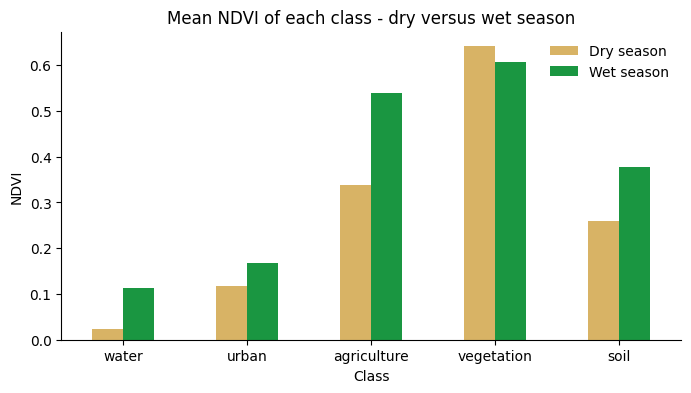

In [48]:
# Mean NDVI of each class in the dry and in the wet season (training pixels)
df_train = geemap.ee_to_df(train)
ndvi_class = df_train.groupby(CLASS_PROPERTY)[["NDVI_dry", "NDVI_wet"]].mean()
ndvi_class.index = ndvi_class.index.astype(int).map(dict(zip(CLASS_CODES, CLASS_NAMES)))

ax = ndvi_class.plot.bar(figsize=(8, 4), rot=0, color=["#d8b365", "#1a9641"])
ax.set_title("Mean NDVI of each class - dry versus wet season")
ax.set_xlabel("Class")
ax.set_ylabel("NDVI")
ax.legend(["Dry season", "Wet season"], frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

---

## 2.5 - The same Random Forest, three inputs

One function trains the Random Forest with a list of bands, classifies the image and evaluates
it on the test samples. We call it three times and show the maps one below the other.

In [59]:
vis_classes = {"min": min(CLASS_CODES), "max": max(CLASS_CODES), "palette": PALETTE}


def classify_season(bands):
    # Train Random Forest with the chosen bands
    rf = ee.Classifier.smileRandomForest(numberOfTrees=100, seed=42).train(
        features=train, classProperty=CLASS_PROPERTY, inputProperties=bands)
    # Classified map and confusion matrix on the test samples
    classified = stack.select(bands).classify(rf)
    cm = test.classify(rf).errorMatrix(CLASS_PROPERTY, "classification", CLASS_CODES)
    return rf, classified, cm


def show_classification(classified, background, title):
    m = geemap.Map()
    m.centerObject(REGION, 14)
    m.addLayer(background, vis_rgb, "RGB", False)
    m.addLayer(classified, vis_classes, title)
    m.add_legend(title=title, legend_dict=dict(zip(CLASS_NAMES, PALETTE)))
    return m


results = {name: classify_season(bands) for name, bands in INPUTS.items()}

### Dry season only

In [60]:
show_classification(results["Dry"][1], dry, "Random Forest - dry season")

Map(center=[-16.16338383351134, -69.08006474980968], controls=(WidgetControl(options=['position', 'transparent…

### Wet season only

In [61]:
show_classification(results["Wet"][1], wet, "Random Forest - wet season")

Map(center=[-16.16338383351134, -69.08006474980968], controls=(WidgetControl(options=['position', 'transparent…

### Dry + wet season (and ΔNDVI)

In [62]:
show_classification(results["Dry + wet"][1], dry, "Random Forest - dry + wet")

Map(center=[-16.16338383351134, -69.08006474980968], controls=(WidgetControl(options=['position', 'transparent…

In [63]:
# Random Forest classifications side by side: dry, wet and dry + wet - the three maps move together
import ipywidgets as widgets
import ipyleaflet

center = REGION.centroid(maxError=1).coordinates().getInfo()[::-1]   # [lat, lon]
names = ["Dry", "Wet", "Dry + wet"]

grid = widgets.GridspecLayout(1, 3, height="400px")
maps = []

for j, name in enumerate(names):
    # Same map that linked_maps creates, placed directly in the grid
    m = geemap.Map(center=center, zoom=14, height="400px", lite_mode=True, add_google_map=False)
    m.addLayer(results[name][1], vis_classes, f"RF - {name}")
    m.add(ipyleaflet.WidgetControl(widget=widgets.Label(f"RF - {name}"), position="topright"))

    # Link zoom and position to the first map
    maps.append(m)
    widgets.jslink((maps[0], "center"), (m, "center"))
    widgets.jslink((maps[0], "zoom"), (m, "zoom"))
    grid[0, j] = m

grid

GridspecLayout(children=(Map(center=[-16.163384962246813, -69.08006474980968], controls=(WidgetControl(options…

### Reading the three maps - what the literature says

**1. Some classes do not depend on the season.** Water, the urban core of Copacabana and the
bare soil on the southern hills look the same in the three maps. They are spectrally distinct
all year round, so one good image is enough for them. Multi-date information matters mainly for
classes that **change in time** - vegetation and crops (Gómez et al., 2016).

**2. The wet-season map turns greener.** Many more pixels are classified as *vegetation* on the
plain and on the hills. In the rainy season the native grassland (pajonal) and the crops are
both photosynthetically active, so "green" stops being a feature of one class only. The
seasonal cycle - the **phenology** - is precisely the information that time series add to land
cover mapping (Gómez et al., 2016; Inglada et al., 2017), but a single wet-season mosaic shows
only **one moment** of that cycle. With few vegetation samples, the model tends to call every
green pixel "vegetation" (commission error).

**3. Dry + wet gives the most conservative map.** It is close to the dry map, with less speckle
than the wet one. Stacking seasonal composites as features of a Random Forest is the strategy
used in large operational products built in Earth Engine, such as the European land cover map
ELC10 (Venter & Sydenham, 2021) and the MapBiomas collections (Souza et al., 2020).

**4. A thin "urban" line along the lake shore.** It appears in all three maps. A 30 m pixel on
the shore mixes water, wet sand and stones, and its average spectrum resembles no pure class -
the classic **mixed pixel** problem (Fisher, 1997). It explains part of the low accuracy of
the urban class.

**5. The wet season has fewer and worse observations.** The wet mosaic was built from fewer
images (see section 2.3), and clouds during the growing season are a known limit of optical
sensors for agricultural mapping (Whitcraft et al., 2015). Fewer clean observations mean a
noisier median and more "salt-and-pepper" in the map.

**Compare the three maps.** Where does the agriculture change? Look at the hill slopes and at
the plain near the lake: fields that the dry map confuses with soil or vegetation often appear
correctly when the wet season is added.

---

## 2.6 - Which input works best?

The same test samples for the three inputs.

In [54]:
# Overall accuracy and Kappa of each input
summary = pd.DataFrame({
    name: {"Overall accuracy": cm.accuracy().getInfo(), "Kappa": cm.kappa().getInfo()}
    for name, (rf, classified, cm) in results.items()
}).T
summary.round(3)

,Overall accuracy,Kappa
Dry,0.945,0.926
Wet,0.961,0.947
Dry + wet,0.929,0.904


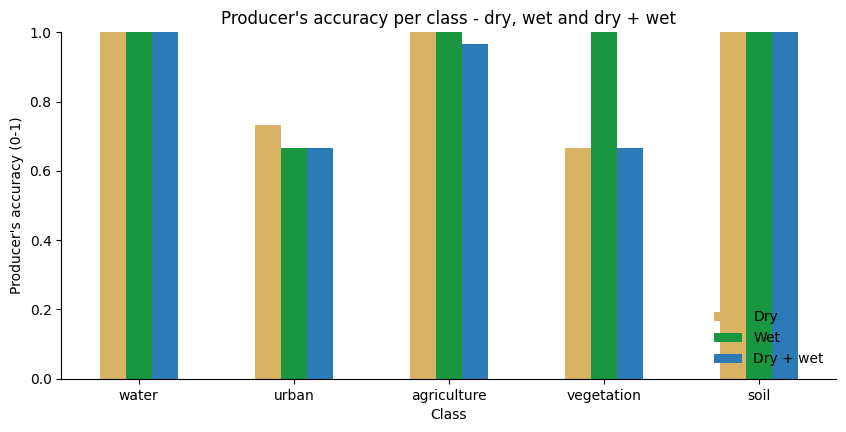

,Dry,Wet,Dry + wet
water,1.00,1.00,1.00
urban,0.73,0.67,0.67
agriculture,1.00,1.00,0.97
vegetation,0.67,1.00,0.67
soil,1.00,1.00,1.00


In [55]:
# Producer's accuracy per class for each input
producers = pd.DataFrame({
    name: cm.producersAccuracy().project([0]).getInfo()
    for name, (rf, classified, cm) in results.items()
}, index=CLASS_NAMES)

ax = producers.plot.bar(figsize=(10, 4.5), rot=0, color=["#d8b365", "#1a9641", "#2c7bb6"])
ax.set_title("Producer's accuracy per class - dry, wet and dry + wet")
ax.set_xlabel("Class")
ax.set_ylabel("Producer's accuracy (0-1)")
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

producers.round(2)

**How to read it.** The overall accuracy may change only a little, because water and urban
are easy in any season. Look at the classes **agriculture** and **vegetation**: that is where
the season makes the difference.

### Why did "dry + wet" not win here? A lesson about evaluation

In our run the overall accuracy was about **0.95 (dry), 0.96 (wet) and 0.93 (dry + wet)** - the
input with the most information came last. This is not a contradiction of the theory; it is a
lesson about **data**:

- **The test set is small.** About 130 test pixels in total, and only 9 for *vegetation*: one
  pixel more or less changes the producer's accuracy of that class by ~11 points. Differences of
  1-3 points in overall accuracy are inside the sampling uncertainty. To claim that one
  classifier is better than another, the test sample must be much larger (Foody, 2009), and
  accuracy should always be reported with a **confidence interval** (Olofsson et al., 2014).
- **The training set is small and unbalanced.** Only 6 training pixels of *vegetation* for 25
  features. Random Forest is robust, but the amount and quality of the training data matter more
  than the algorithm or its parameters (Pelletier et al., 2016; Belgiu & Drăguţ, 2016; Maxwell
  et al., 2018). Adding features without adding samples can make the model worse.
- **The seasonal signal helps only if the samples represent it.** Phenology separates crops
  from grassland when both classes are well sampled in the seasons used.

The next cell computes the 95% confidence interval of the overall accuracy of each input.

In [56]:
# 95% confidence interval of the overall accuracy: OA ± 1.96 * sqrt(OA * (1 - OA) / n)
n_test = test.size().getInfo()
ci = summary[["Overall accuracy"]].copy()
ci["± 95% CI"] = 1.96 * (ci["Overall accuracy"] * (1 - ci["Overall accuracy"]) / n_test) ** 0.5
ci["lower"] = ci["Overall accuracy"] - ci["± 95% CI"]
ci["upper"] = ci["Overall accuracy"] + ci["± 95% CI"]

print("Test pixels:", n_test)
ci.round(3)

Test pixels: 127


,Overall accuracy,± 95% CI,lower,upper
Dry,0.945,0.040,0.905,0.985
Wet,0.961,0.034,0.927,0.994
Dry + wet,0.929,0.045,0.885,0.974


If the intervals **overlap**, the three inputs are statistically equivalent with this test set.
To really answer "does the wet season help?", collect more samples - especially of
*vegetation* and *agriculture* - and run the comparison again (exercise 4 below).

### Which variables did the dry + wet model use?

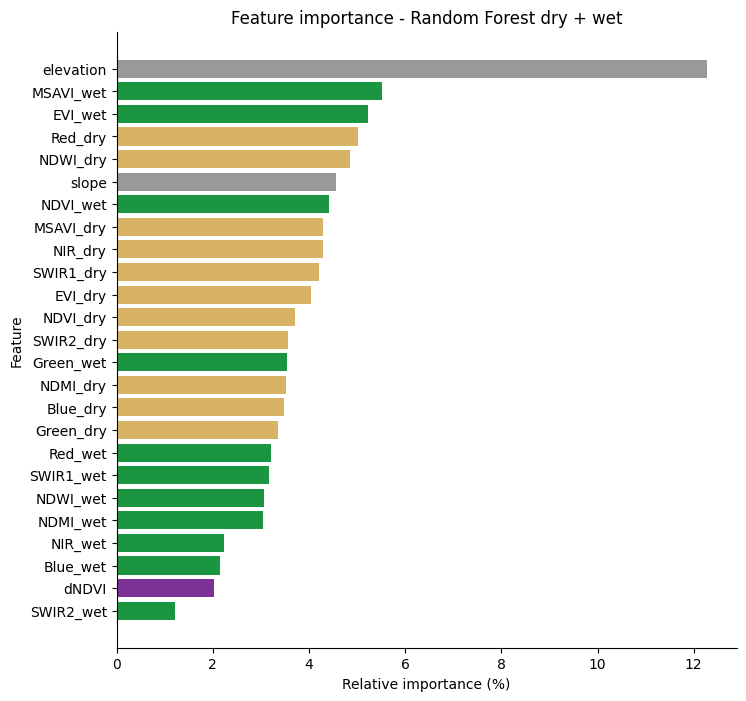

In [57]:
# Feature importance of the dry + wet Random Forest
rf_both = results["Dry + wet"][0]
importance = pd.Series(ee.Dictionary(rf_both.explain()).get("importance").getInfo())
importance = (100 * importance / importance.sum()).sort_values()

# Colour by season: brown = dry, green = wet, purple = ΔNDVI, grey = terrain
colours = ["#d8b365" if b.endswith("_dry") else "#1a9641" if b.endswith("_wet")
           else "#7b3294" if b == "dNDVI" else "#999999" for b in importance.index]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(importance.index, importance.values, color=colours)
ax.set_title("Feature importance - Random Forest dry + wet")
ax.set_xlabel("Relative importance (%)")
ax.set_ylabel("Feature")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

Brown bars are dry-season bands, green bars wet-season bands, purple is ΔNDVI and grey is
terrain. If wet-season bands and ΔNDVI are near the top, the model is using the **seasonal
change** to separate the classes - exactly the information a single dry image does not have.

> **Watch the clouds.** Pixels without a clear wet-season observation are masked in the wet
> mosaic, so they stay without class in the *Wet* and *Dry + wet* maps. If you see holes, widen
> the wet-season window or raise the cloud filter.

---

## 2.7 - Ejercicio / Exercise

1. **Another season split.** Use only the peak of the rains (January - March) for the wet
   mosaic. How many images are left, and what happens to the accuracy?
2. **Fewer bands.** Train a model with only `NDVI_dry`, `NDVI_wet`, `dNDVI`, `elevation` and
   `slope`. Is it much worse than the full dry + wet model?
3. **Another year.** Build the mosaics for the 2022/23 agricultural year and classify with the
   same samples. Do the agricultural fields stay in the same place?
4. **More samples.** Collect at least 30 more samples of *vegetation* and *agriculture* in the
   Sample Collector, re-run the notebook and compare the confidence intervals of section 2.6
   again. Does *dry + wet* now come out on top?

**Entregable / Deliverable**: the table of overall accuracy of the three inputs, the producer's
accuracy chart and a short paragraph explaining which classes benefited from the wet season.

---

## Referencias / References

- Gómez, C., White, J. C., Wulder, M. A. (2016). Optical remotely sensed time series data for
  land cover classification: a review. *ISPRS Journal of Photogrammetry and Remote Sensing*,
  116, 55-72. <https://doi.org/10.1016/j.isprsjprs.2016.03.008>
- Belgiu, M., Drăguţ, L. (2016). Random forest in remote sensing: a review of applications and
  future directions. *ISPRS Journal of Photogrammetry and Remote Sensing*, 114, 24-31.
  <https://doi.org/10.1016/j.isprsjprs.2016.01.011>
- Inglada, J. et al. (2017). Operational high resolution land cover map production at the
  country scale using satellite image time series. *Remote Sensing*, 9(1), 95.
  <https://doi.org/10.3390/rs9010095>
- Venter, Z. S., Sydenham, M. A. K. (2021). Continental-scale land cover mapping at 10 m
  resolution over Europe (ELC10). *Remote Sensing*, 13(12), 2301.
  <https://doi.org/10.3390/rs13122301>
- Souza, C. M. et al. (2020). Reconstructing three decades of land use and land cover changes in
  Brazilian biomes with Landsat archive and Earth Engine. *Remote Sensing*, 12(17), 2735.
  <https://doi.org/10.3390/rs12172735>
- Pelletier, C. et al. (2016). Assessing the robustness of Random Forests to map land cover with
  high resolution satellite image time series over large areas. *Remote Sensing of
  Environment*, 187, 156-168. <https://www.sciencedirect.com/science/article/pii/S0034425716303820>
- Whitcraft, A. K., Vermote, E. F., Becker-Reshef, I., Justice, C. O. (2015). Cloud cover
  throughout the agricultural growing season: impacts on passive optical earth observations.
  *Remote Sensing of Environment*, 156, 438-447.
  <https://www.sciencedirect.com/science/article/abs/pii/S0034425714004179>
- Fisher, P. (1997). The pixel: a snare and a delusion. *International Journal of Remote
  Sensing*, 18(3), 679-685. <https://ui.adsabs.harvard.edu/abs/1997IJRS...18..679F>
- Foody, G. M. (2009). Sample size determination for image classification accuracy assessment
  and comparison. *International Journal of Remote Sensing*, 30(20), 5273-5291.
  <https://doi.org/10.1080/01431160903130937>
- Olofsson, P. et al. (2014). Good practices for estimating area and assessing accuracy of land
  change. *Remote Sensing of Environment*, 148, 42-57.
  <https://ui.adsabs.harvard.edu/abs/2014RSEnv.148...42O/abstract>
- Maxwell, A. E., Warner, T. A., Fang, F. (2018). Implementation of machine-learning
  classification in remote sensing: an applied review. *International Journal of Remote
  Sensing*, 39(9), 2784-2817. <https://doi.org/10.1080/01431161.2018.1433343>
- Earth Engine - supervised classification:
  <https://developers.google.com/earth-engine/guides/classification>
- geemap split maps: <https://geemap.org>